# Medicaid Expansion Difference-in-Differences Analysis

**Question:** Did Medicaid expansion increase health insurance coverage in expansion states relative to non-expansion states?

This notebook uses a synthetic Medicaid expansion microdata set to compare insurance coverage before and after expansion, with never-expansion states as the comparison group.


## Analysis Plan

1. Load the synthetic Medicaid expansion data.
2. Check state expansion coding and basic data quality.
3. Compare raw coverage rates by treatment and post-period status.
4. Estimate Difference-in-Differences models with progressively stronger controls.
5. Visualize pre/post coverage trends and inspect the low-income subgroup.


In [49]:
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from matplotlib import pyplot as plt

sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.float_format", "{:.3f}".format)


## Data Load

The data is stored at `synthetic_medicaid_did_micro_v1.csv`. Each row represents an individual observation for a state-year combination.


In [27]:
df = pd.read_csv("synthetic_medicaid_did_micro_v1.csv")
df.head()


,person_id,state,year,expanded_state,expansion_year,post,age,female,low_income,insured
0,1,Texas,2011,0,Never,0,34,1,1,1
1,2,Texas,2011,0,Never,0,39,1,0,1
2,3,Texas,2011,0,Never,0,48,1,1,0
3,4,Texas,2011,0,Never,0,38,0,0,0
4,5,Texas,2011,0,Never,0,42,0,1,1


In [28]:
df.shape


(9000, 10)

## Data Dictionary

| Column | Meaning |
| --- | --- |
| `state` | U.S. state identifier |
| `year` | Observation year |
| `expanded_state` | Flag for states that eventually expanded Medicaid |
| `expansion_year` | Year the state expanded Medicaid; `Never` for non-expansion states |
| `post` | Flag for observations at or after the state's expansion year |
| `age` | Individual age |
| `female` | Gender indicator |
| `low_income` | Low-income indicator |
| `insured` | Insurance coverage indicator |

**Outcome:** `insured`  
**Treatment timing:** `post` interacted with `expanded_state`  
**Primary estimate:** coefficient on `did_interactionterm`


## Data Quality Checks

Before modeling, confirm that each state has one expansion-year assignment and that expansion flags are consistent with `expansion_year`.


### 1. Duplicate Medicaid Expansion Assignments

**Finding:** no duplicate expansion-year assignments appear after deduplicating by `state` and `expansion_year`.


In [32]:
unique_df = df.drop_duplicates(subset=["state", "expansion_year"])
unique_df.groupby(["state"], as_index=False)["expansion_year"].size()


,state,size
0,Alabama,1
1,California,1
2,Florida,1
3,Georgia,1
4,Louisiana,1
5,Michigan,1
6,New York,1
7,Ohio,1
8,Texas,1
9,Virginia,1


### 2. Expansion Coding Consistency

A non-expansion state should have `expanded_state == 0` and `expansion_year == "Never"`. Expansion states should have a concrete expansion year.


In [38]:
inconsistent_expansion_flags = df[
    ((df["expanded_state"] == 0) & (df["expansion_year"] != "Never"))
    | ((df["expanded_state"] != 0) & (df["expansion_year"] == "Never"))
]

inconsistent_expansion_flags


,person_id,state,year,expanded_state,expansion_year,post,age,female,low_income,insured


## Exploratory Analysis

Start with the timing of adoption and the raw coverage averages that motivate the DiD setup.


In [25]:
unique_df = df.drop_duplicates(subset=["state", "expansion_year"])
expansion_year_counts = unique_df.groupby("expansion_year", as_index=False)["state"].size()
expansion_year_counts


,expansion_year,size
0,2014,4
1,2016,1
2,2019,1
3,Never,4


Text(0.5, 1.0, 'Year-Wise Count of states adopting Medicaid')

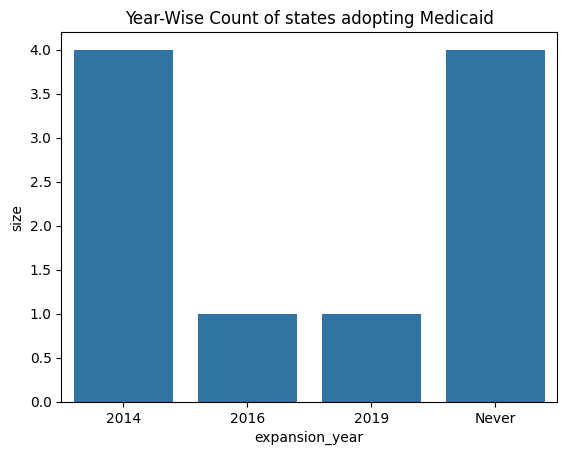

In [26]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=expansion_year_counts,
    x="expansion_year",
    y="size",
)
plt.title("States Adopting Medicaid Expansion by Year")
plt.xlabel("Expansion year")
plt.ylabel("Number of states")
plt.show()


In [40]:
df.groupby(["expanded_state", "post"])["insured"].mean().reset_index()


,expanded_state,post,insured
0,0,0,0.686111
1,1,0,0.652800
2,1,1,0.721724


## Model Preparation

Aggregate to the state-year level for trend visualization, then create the interaction term used in the regression models.


In [42]:
state_year = (
    df.groupby(["state", "year", "expanded_state", "post"], as_index=False)["insured"]
    .mean()
    .rename(columns={"insured": "insured_rate"})
)

state_year


,state,year,expanded_state,post,insured_rate
0,Alabama,2011,0,0,0.56
1,Alabama,2012,0,0,0.61
2,Alabama,2013,0,0,0.61
3,Alabama,2014,0,0,0.52
4,Alabama,2015,0,0,0.59
...,...,...,...,...,...
85,Virginia,2015,1,0,0.63
86,Virginia,2016,1,0,0.67
87,Virginia,2017,1,0,0.67
88,Virginia,2018,1,0,0.59


In [45]:
df["did_interactionterm"] = df["expanded_state"] * df["post"]


## Difference-in-Differences Models

The coefficient on `did_interactionterm` is the DiD estimate. The preferred specifications include state and year fixed effects to absorb persistent state differences and common year shocks.


In [51]:
model1 = smf.ols(
    "insured ~ expanded_state + post + did_interactionterm",
    data=df,
).fit()

print(model1.summary())


                            OLS Regression Results                            
Dep. Variable:                insured   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     9.819
Date:                Thu, 16 Apr 2026   Prob (F-statistic):           1.84e-06
Time:                        19:09:23   Log-Likelihood:                -5828.9
No. Observations:                9000   AIC:                         1.167e+04
Df Residuals:                    8996   BIC:                         1.169e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               0.6880    

### State and Year Fixed Effects

This specification compares treated-state post-expansion changes against common year effects and state-specific baselines.


In [53]:
model2 = smf.ols(
    "insured ~ did_interactionterm + C(state) + C(year)",
    data=df,
).fit()

print(model2.summary())


                            OLS Regression Results                            
Dep. Variable:                insured   R-squared:                       0.026
Model:                            OLS   Adj. R-squared:                  0.024
Method:                 Least Squares   F-statistic:                     13.24
Date:                Thu, 16 Apr 2026   Prob (F-statistic):           7.47e-40
Time:                        19:11:50   Log-Likelihood:                -5725.7
No. Observations:                9000   AIC:                         1.149e+04
Df Residuals:                    8981   BIC:                         1.162e+04
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  0

### Adjusted Fixed Effects Model

Add individual covariates to check whether the treatment estimate is sensitive to observed demographic composition.


In [54]:
model3 = smf.ols(
    "insured ~ did_interactionterm + age + female + low_income + C(state) + C(year)",
    data=df,
).fit()

print(model3.summary())


                            OLS Regression Results                            
Dep. Variable:                insured   R-squared:                       0.026
Model:                            OLS   Adj. R-squared:                  0.024
Method:                 Least Squares   F-statistic:                     11.45
Date:                Thu, 16 Apr 2026   Prob (F-statistic):           1.28e-38
Time:                        19:12:35   Log-Likelihood:                -5724.6
No. Observations:                9000   AIC:                         1.149e+04
Df Residuals:                    8978   BIC:                         1.165e+04
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  0

## Trend Check

The plot below compares average insurance coverage over time for expansion and control states. It provides a visual check for whether the treatment group diverges after expansion.


In [56]:
trend_df = (
    df.groupby(["year", "expanded_state"], as_index=False)["insured"]
    .mean()
    .rename(columns={"insured": "insured_rate"})
)

trend_df


,year,expanded_state,insured_rate
0,2011,0,0.677500
1,2011,1,0.643333
2,2012,0,0.670000
3,2012,1,0.668333
4,2013,0,0.682500
5,2013,1,0.646667
6,2014,0,0.647500
7,2014,1,0.693333
8,2015,0,0.685000
9,2015,1,0.671667


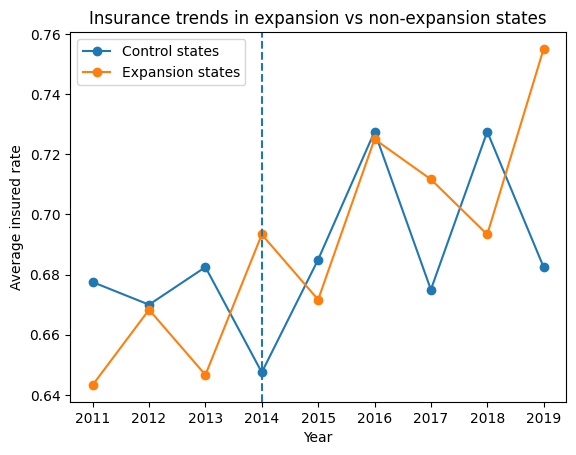

In [57]:
plt.figure(figsize=(10, 5))

for group_value, group_name in [(0, "Control states"), (1, "Expansion states")]:
    temp = trend_df[trend_df["expanded_state"] == group_value]
    plt.plot(temp["year"], temp["insured_rate"], marker="o", label=group_name)

plt.axvline(x=2014, linestyle="--", color="gray", label="2014 reference")
plt.xlabel("Year")
plt.ylabel("Average insured rate")
plt.title("Insurance Coverage Trends by Expansion Status")
plt.legend()
plt.tight_layout()
plt.show()


## Low-Income Subgroup

Because Medicaid eligibility is most directly tied to income, estimate the fixed-effects model again for low-income individuals only.


In [59]:
low_income_df = df[df["low_income"] == 1]

model_low_income = smf.ols(
    "insured ~ did_interactionterm + C(state) + C(year)",
    data=low_income_df,
).fit()

print(model_low_income.summary())


                            OLS Regression Results                            
Dep. Variable:                insured   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                  0.024
Method:                 Least Squares   F-statistic:                     5.634
Date:                Thu, 16 Apr 2026   Prob (F-statistic):           2.08e-13
Time:                        19:13:47   Log-Likelihood:                -2151.2
No. Observations:                3383   AIC:                             4340.
Df Residuals:                    3364   BIC:                             4457.
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  0

## Summary

- The fixed-effects DiD estimate is positive: Medicaid expansion is associated with roughly a **3.8 percentage-point** increase in insurance coverage in the full sample.
- Adding age, gender, and low-income controls leaves the estimate essentially unchanged.
- The low-income subgroup estimate is larger, at roughly **5.6 percentage points**, but is less precisely estimated in this synthetic sample.
- The simple no-fixed-effects model is less reliable here; use the fixed-effects models as the main readout.
